In [187]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor


from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [188]:
data=pd.read_csv('Exam_Score_Prediction.csv')
data

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19997,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,19998,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19999,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,20000,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


In [189]:
data.shape

(20000, 13)

In [190]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [191]:
(data.isnull().sum()/len(data))*100

,0
student_id,0.0
age,0.0
gender,0.0
course,0.0
study_hours,0.0
class_attendance,0.0
internet_access,0.0
sleep_hours,0.0
sleep_quality,0.0
study_method,0.0


In [192]:
data.duplicated().sum()

np.int64(0)

In [193]:
corr=data.corr(numeric_only=True)
corr

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
student_id,1.000000,-0.002574,0.002116,0.001128,-0.000560,0.003269
age,-0.002574,1.000000,0.002955,0.008449,-0.000385,0.006522
study_hours,0.002116,0.002955,1.000000,-0.001645,-0.004533,0.717788
class_attendance,0.001128,0.008449,-0.001645,1.000000,0.007187,0.308850
sleep_hours,-0.000560,-0.000385,-0.004533,0.007187,1.000000,0.133222
exam_score,0.003269,0.006522,0.717788,0.308850,0.133222,1.000000


In [194]:
data.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


<Axes: >

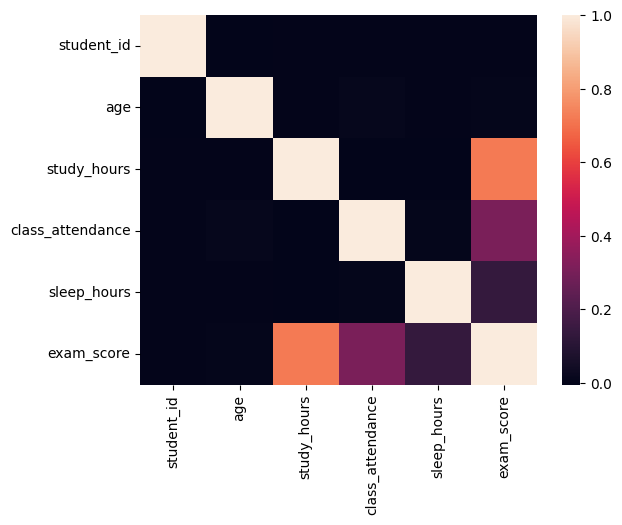

In [195]:
sns.heatmap(corr)

In [196]:
data.drop(columns=['student_id'],inplace=True)

In [197]:
data

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


In [198]:
data.columns

Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

# Univariate Analysis

In [199]:
num=['age', 'study_hours', 'class_attendance',
       'sleep_hours']

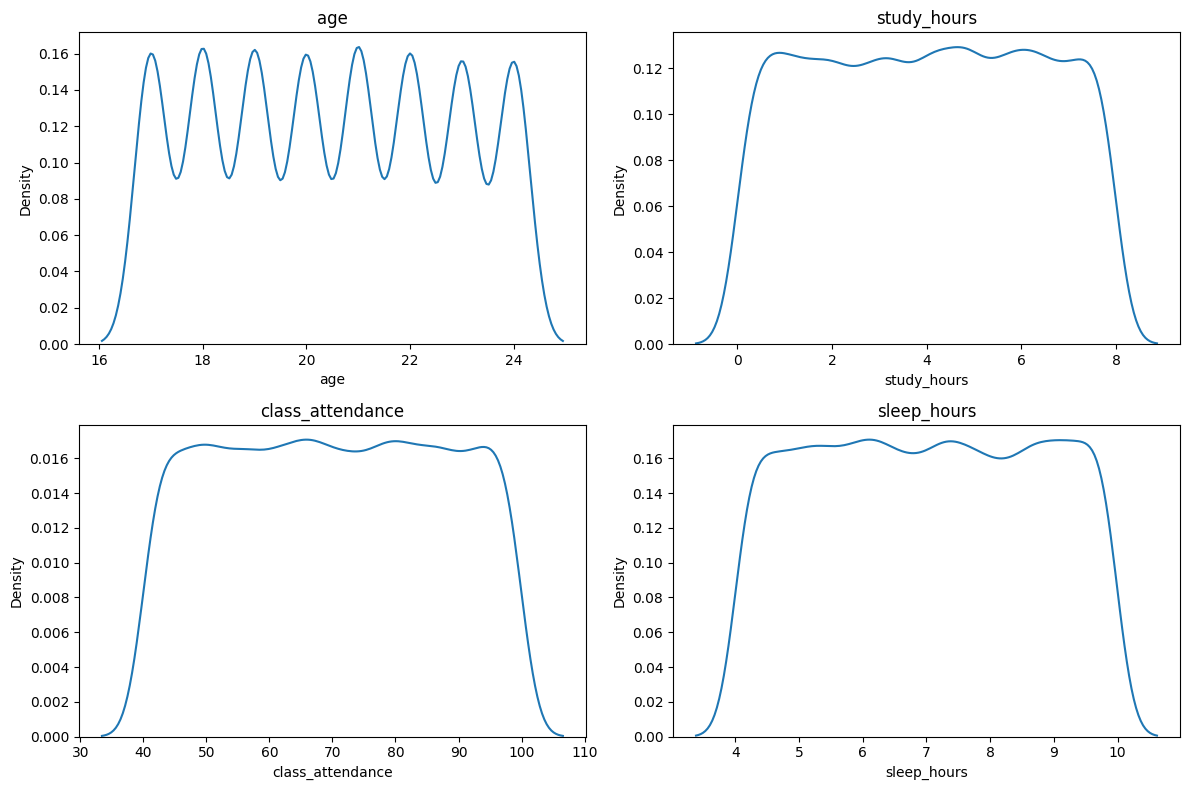

In [200]:
plt.figure(figsize=(12,8))

for index,col in enumerate(num):

  plt.subplot(2,2,index+1)
  sns.kdeplot(data[col])
  plt.title(col)
  plt.xlabel(col)
  plt.tight_layout()

In [201]:
cat=[ 'gender', 'course',
       'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty']

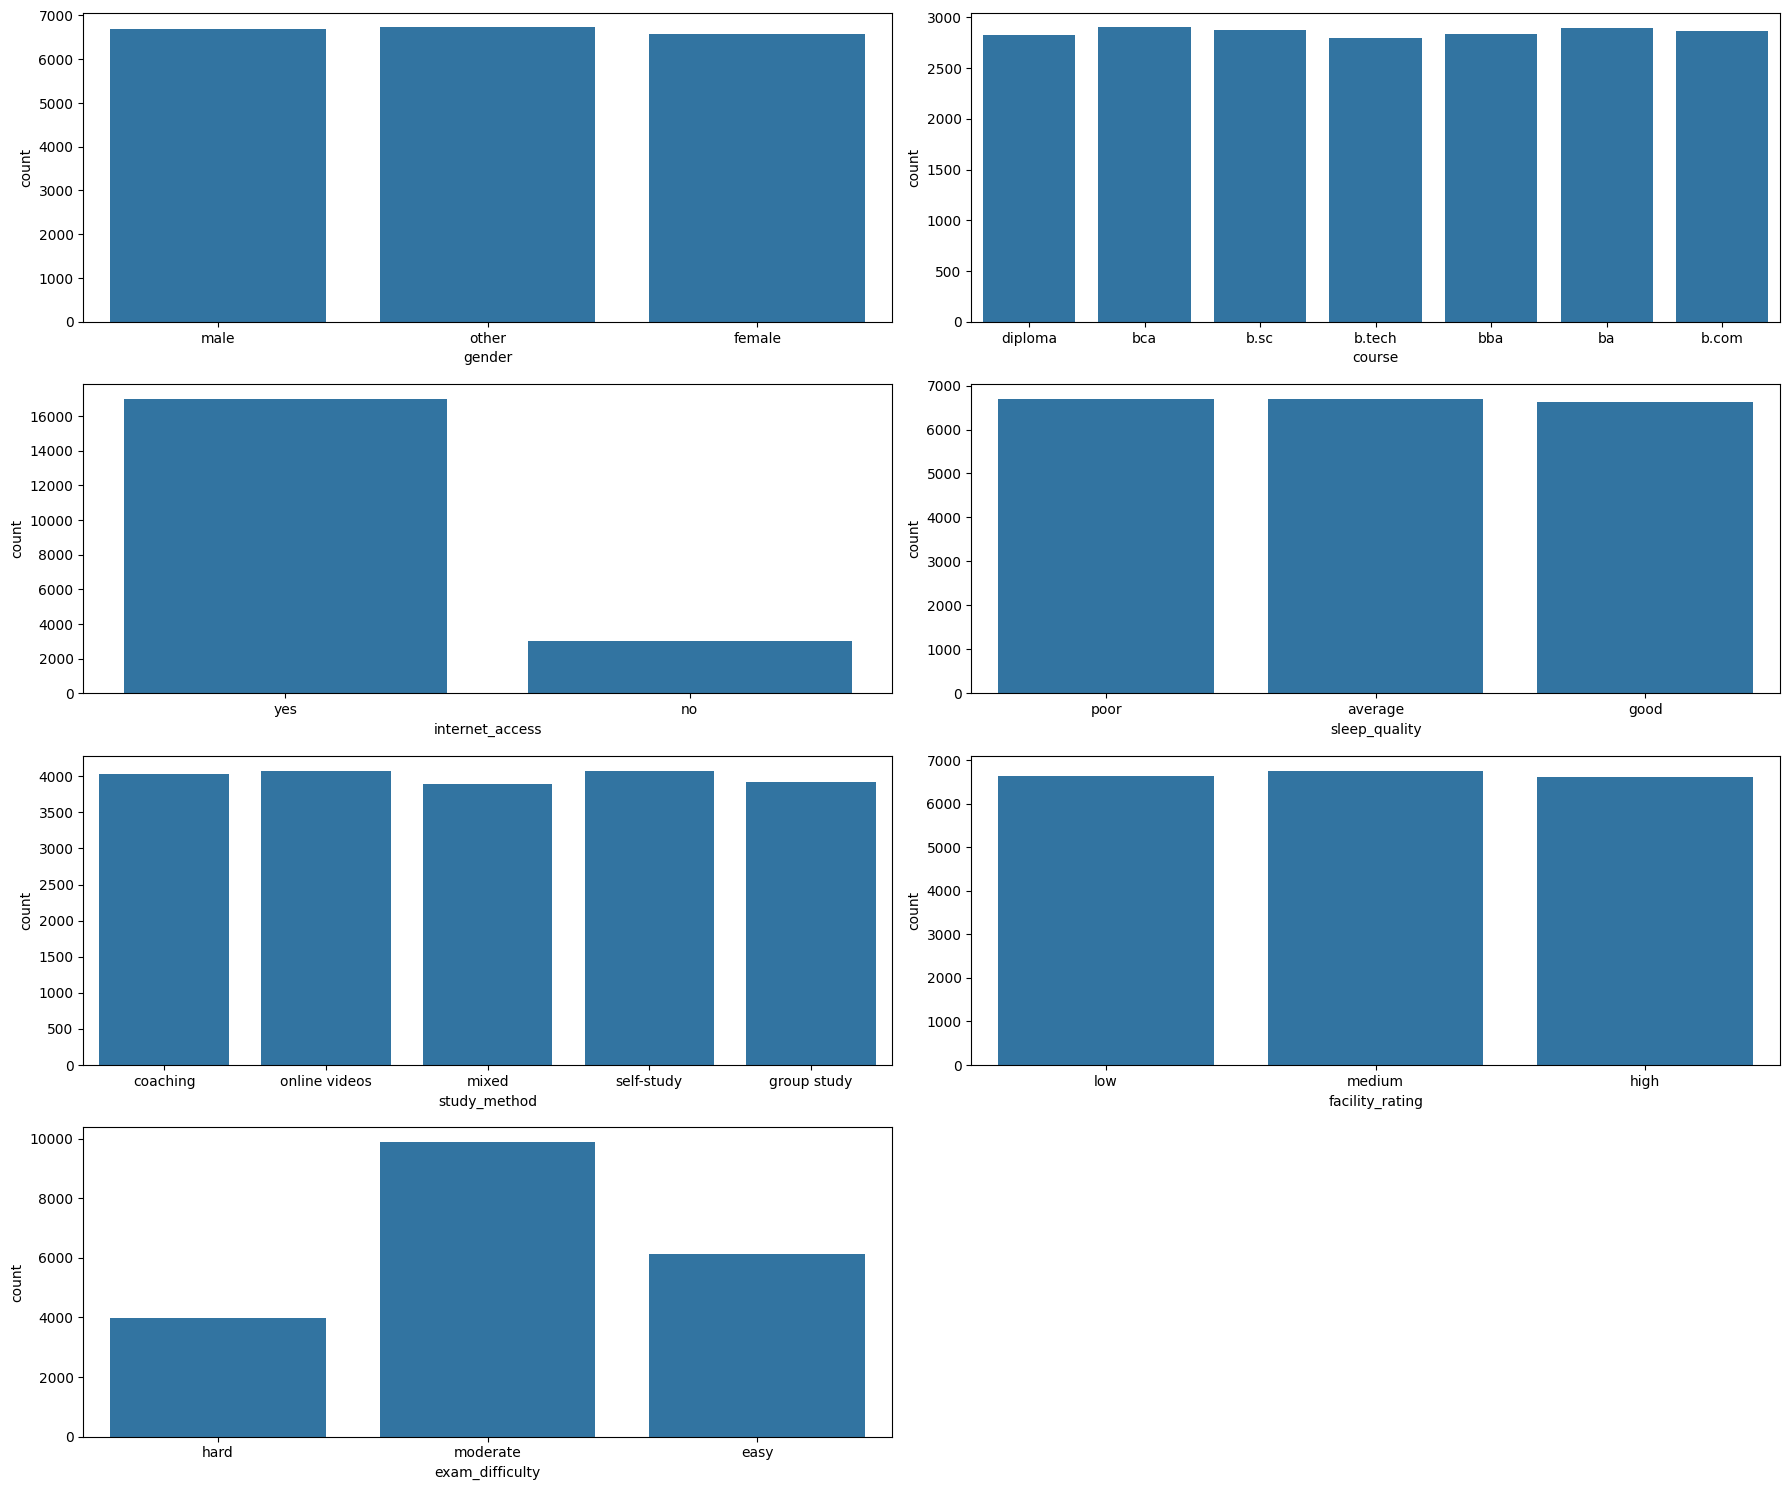

In [202]:
plt.figure(figsize=(18,15))

for index,col in enumerate (cat):

  plt.subplot(4,2,index+1)
  sns.countplot(x=data[col])
  plt.tight_layout()

# Bivariate Analysis

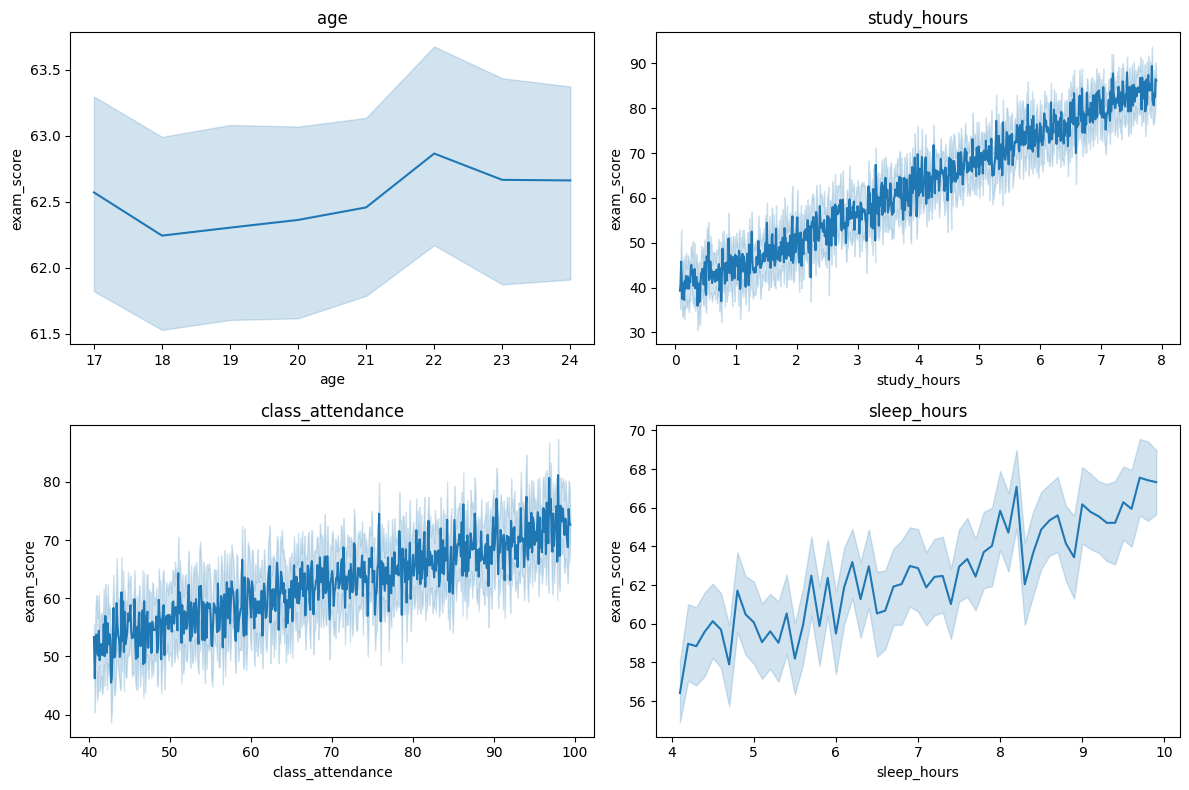

In [203]:
plt.figure(figsize=(12,8))

for index,col in enumerate(num):

  plt.subplot(2,2,index+1)
  sns.lineplot(x=data[col],y=data['exam_score'])
  plt.title(col)
  plt.xlabel(col)
  plt.tight_layout()

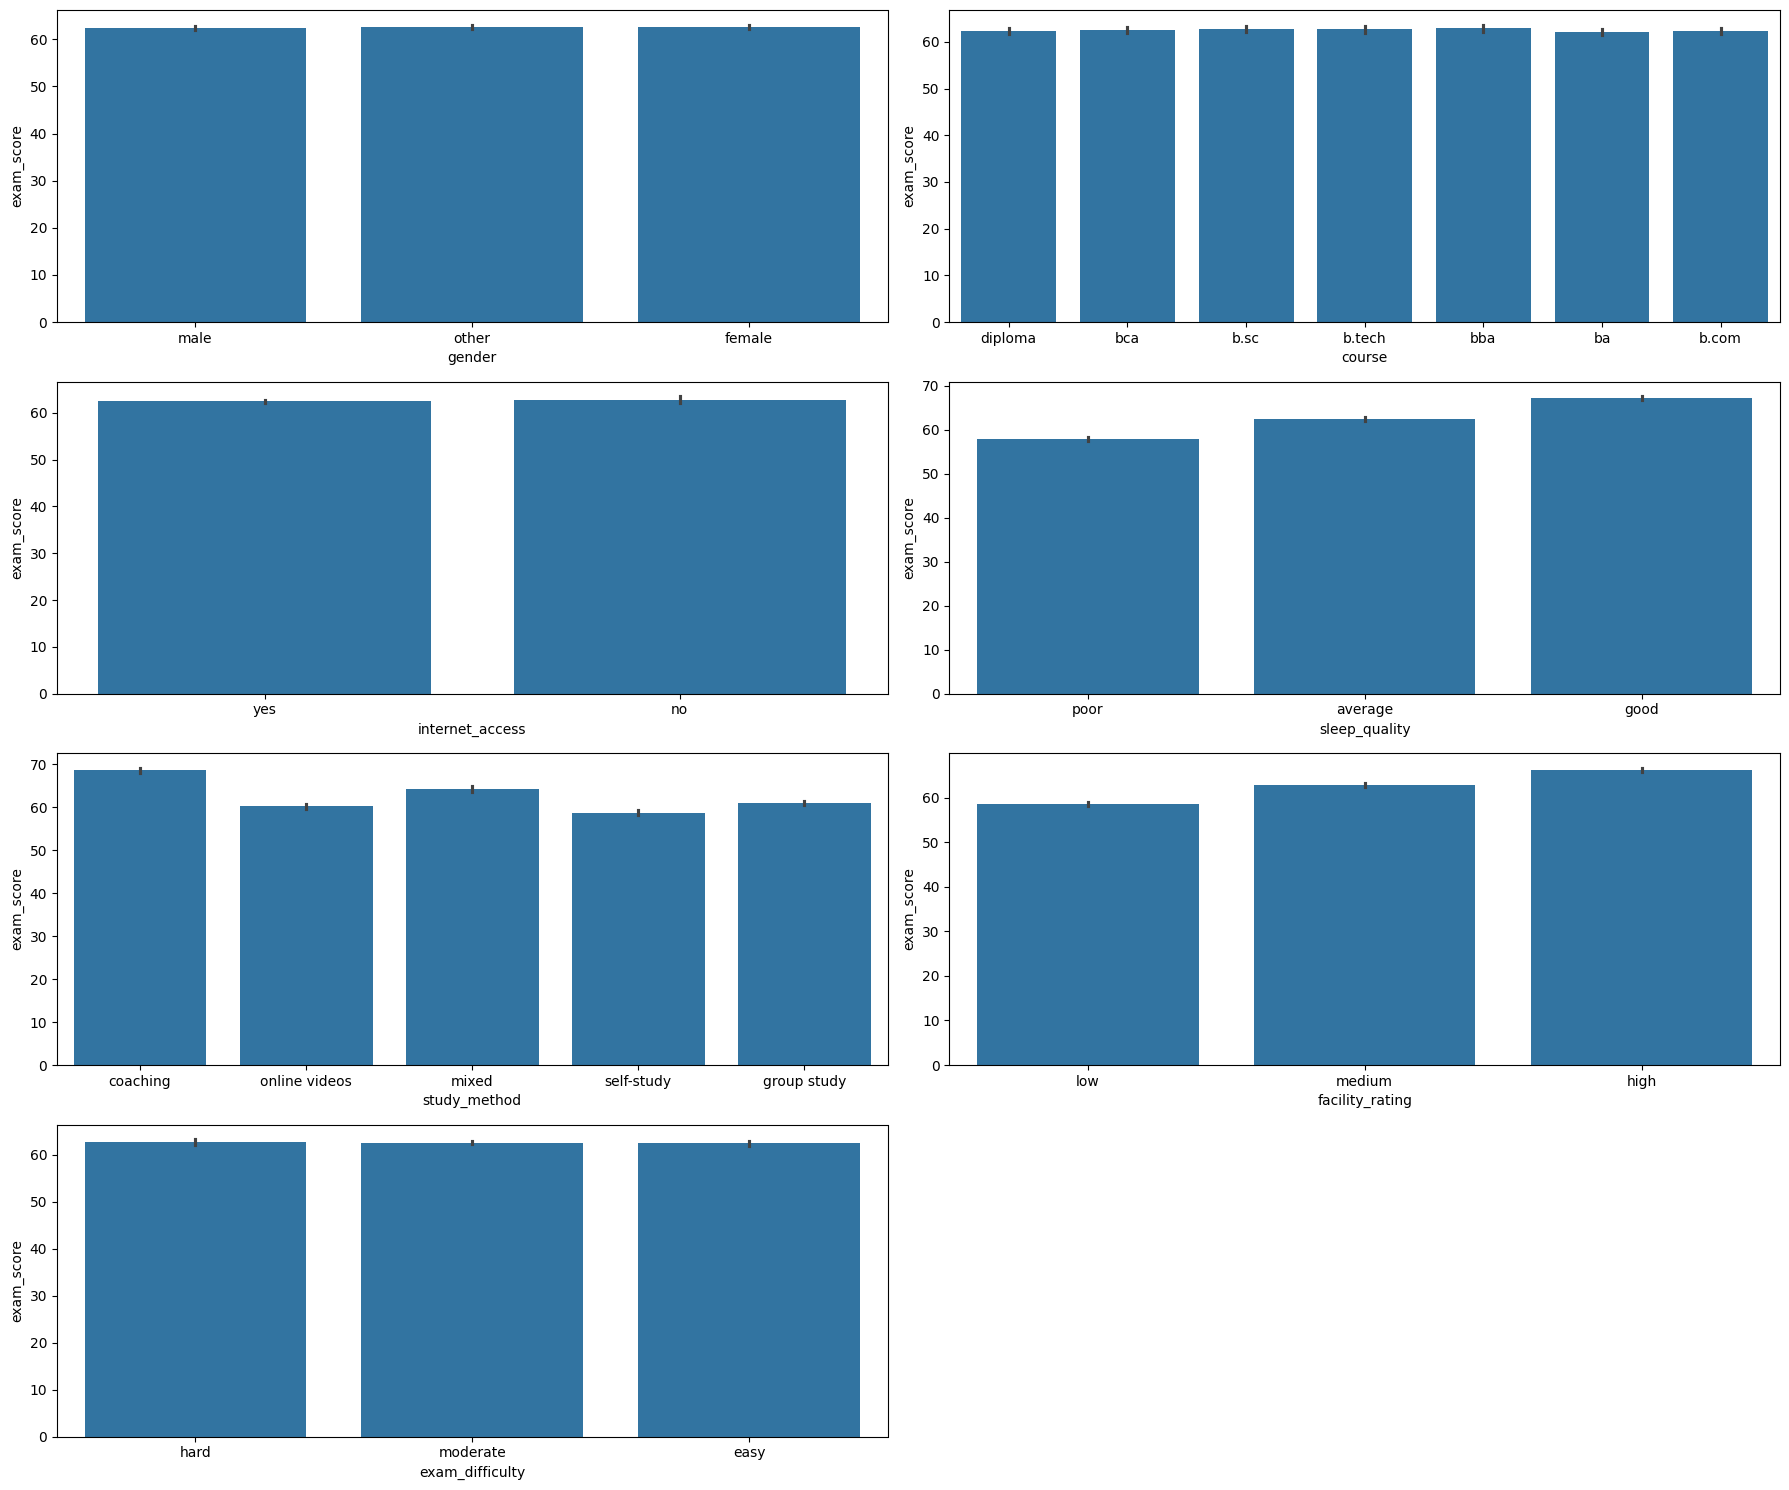

In [204]:
plt.figure(figsize=(18,15))

for index,col in enumerate (cat):

  plt.subplot(4,2,index+1)
  sns.barplot(x=data[col],y=data['exam_score'])
  plt.tight_layout()


In [205]:
for i in num:
  print(f'Skewness in {i} ',data[i].skew())


Skewness in age  0.0147518099648366
Skewness in study_hours  -0.010298675729341284
Skewness in class_attendance  -0.0012902833337919094
Skewness in sleep_hours  -0.0007711987296686071


In [206]:
data

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


In [207]:
cat

['gender',
 'course',
 'internet_access',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty']

In [208]:
categories=[
    ['poor','average','good'],
    ['low','medium','high'],
    ['easy','moderate','hard']

]

In [209]:
trf=ColumnTransformer([
    ('ohe',OneHotEncoder(handle_unknown='ignore'),['gender','course','internet_access','study_method'] ) ,
    ('ordinal',OrdinalEncoder(categories=categories),['sleep_quality','facility_rating','exam_difficulty'])
],remainder='passthrough')

In [210]:
models={
    'lr':LinearRegression(),
    'rf':RandomForestRegressor(),
    'dt': DecisionTreeRegressor(),
    'xg': XGBRegressor(),
    'gb':GradientBoostingRegressor()
}

In [211]:
x=data.drop(columns=['exam_score'])
x

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate
...,...,...,...,...,...,...,...,...,...,...,...
19995,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy
19996,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate
19997,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy
19998,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate


In [212]:
y=data['exam_score']
y

,exam_score
0,58.9
1,54.8
2,90.3
3,29.7
4,43.7
...,...
19995,86.5
19996,60.9
19997,64.5
19998,79.0


In [213]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [218]:
for name,model in models.items():

  pipe=Pipeline([
    ('trf',trf),
    ('model',model)

])
  pipe.fit(x_train,y_train)
  y_pred=pipe.predict(x_test)

  print(f"  for {name} : ")
  print("r2_score : ",r2_score(y_test,y_pred))
  print(f"MAE : ",mean_absolute_error(y_test,y_pred))
  print(f"MSE : ",mean_squared_error(y_test,y_pred))

  print(" ")

  print("Train R2 :", r2_score(y_train, pipe.predict(x_train)))
  print("Test R2 :", r2_score(y_test, y_pred))

  print(" ")

  for lr : 
r2_score :  0.7331071422534647
MAE :  7.862054754381779
MSE :  95.46677929362923
 
Train R2 : 0.7319293229278436
Test R2 : 0.7331071422534647
 
  for rf : 
r2_score :  0.7022859553866587
MAE :  8.338098125
MSE :  106.4914259215859
 
Train R2 : 0.9586653119800806
Test R2 : 0.7022859553866587
 
  for dt : 
r2_score :  0.3982568008883106
MAE :  11.704116249999998
MSE :  215.24174781624998
 
Train R2 : 1.0
Test R2 : 0.3982568008883106
 
  for xg : 
r2_score :  0.695687518833875
MAE :  8.378742020633698
MSE :  108.85166699879697
 
Train R2 : 0.8582903485371811
Test R2 : 0.695687518833875
 
  for gb : 
r2_score :  0.7288786213050773
MAE :  7.942089986080542
MSE :  96.97930862666051
 
Train R2 : 0.7427310465417201
Test R2 : 0.7288786213050773
 
